In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from PIL import Image

from bovw import BagOfVisualWordsClassifier, BoVWConfig

In [3]:
dataset_root = Path('dataset')
feature_extractor = 'SIFT' 
vocabulary_size = 500      
use_tfidf = True            

config = BoVWConfig(
    feature_extractor=feature_extractor,
    vocabulary_size=vocabulary_size,
    max_descriptors_per_image=2000,
    max_vocabulary_descriptors=5000000,
    random_state=42,
)
model = BagOfVisualWordsClassifier(config)

print('Training...')
model.fit(dataset_root / 'train')
print('Training finished.')

Training...
Training finished.


In [20]:
# Build an index from the test set
test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])
test_images.append("./mine1.jpg")
test_images.append("./mine2.jpg")
print(f'Found {len(test_images)} test images to index')


print('Indexing... (this may take a while)')
model.index_dataset(test_images, use_tfidf=use_tfidf)
print('Index built. Indexed features shape:', getattr(model, '_index_features').shape)

Found 212 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (212, 500)


In [13]:
index_path = Path('artifacts') / 'tfidf_index.pkl'
saved_index = model.save_index(index_path)
loaded_model = model.load_index(saved_index)
print('Saved index to:', saved_index)
print('Loaded index entries:', len(loaded_model._index_paths))
print('TF-IDF enabled:', getattr(loaded_model, '_index_use_tfidf', False))

Saved index to: artifacts\tfidf_index.pkl
Loaded index entries: 210
TF-IDF enabled: True


In [107]:
indices = [i for i, path in enumerate(test_images) if 'stop_sign' in path.parts]

# Wypisanie wyników
print(f"Indeksy plików w folderze 'windsor_chair': {indices}")

Indeksy plików w folderze 'windsor_chair': []


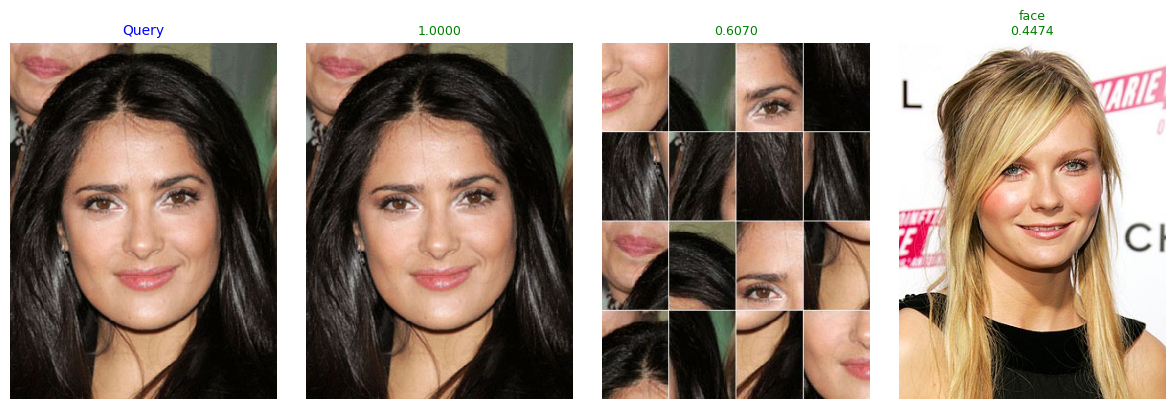

In [22]:
query_path = "./mine1.jpg"
results = model.query(query_path, top_k=8, metric='cosine', use_tfidf=use_tfidf)
n = len(results) + 1
n = 4
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))

qimg = Image.open(query_path).convert('RGB')
axes[0].imshow(qimg)
axes[0].set_title(f'Query', fontsize=10, color='blue')
axes[0].axis('off')

mine = []

mine.append(results[0])
mine.append(results[1])
mine.append(results[5])

for i, (p, score) in enumerate(mine, start=1):
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    
    title_color = 'green'
    
    axes[i].set_title(f'{p.parent.name}\n{score:.4f}', fontsize=9, color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

dataset\test\city\city_test-002.jpg
dataset\test\city\city_test-024.jpg
dataset\test\green\green_test-005.jpg
dataset\test\office\office_test-028.jpg
dataset\test\green\green_test-009.jpg
dataset\test\green\green_test-001.jpg
dataset\test\house_indoor\house_indoor_test-030.jpg
dataset\test\green\green_test-028.jpg
dataset\test\green\green_test-019.jpg
dataset\test\office\office_test-018.jpg


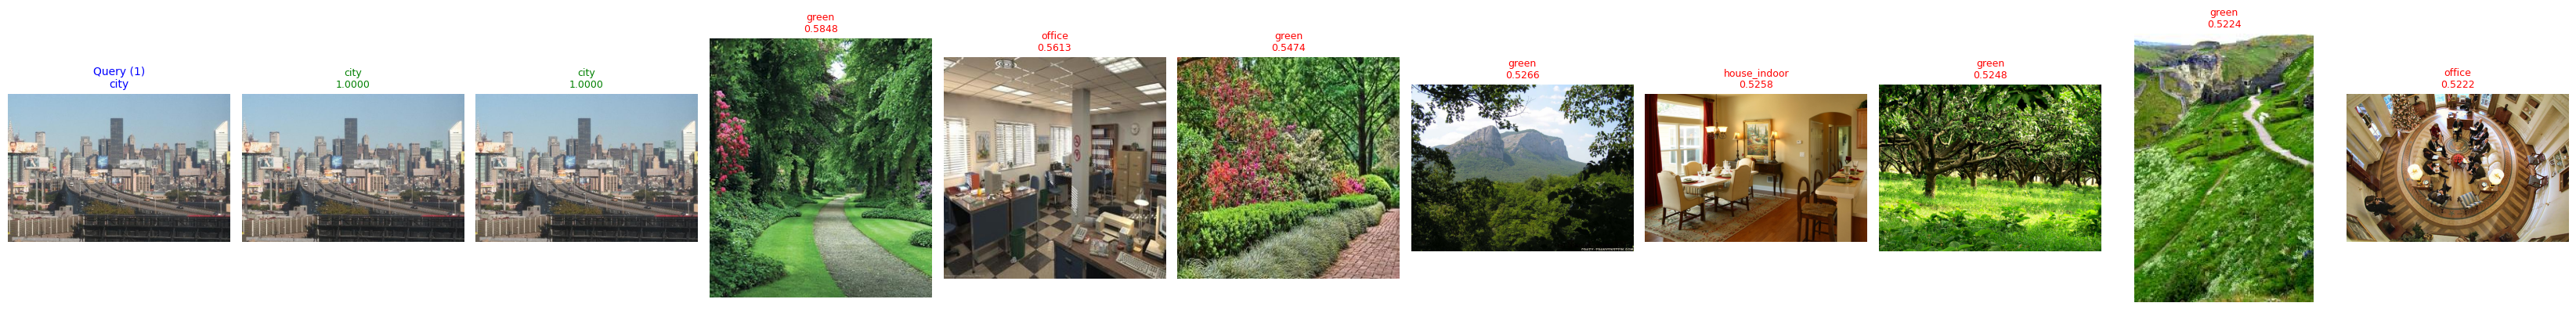

In [ ]:
k = 10

query_idx = 1

query_path = test_images[query_idx]

results = loaded_model.query(query_path, top_k=k, metric='cosine', use_tfidf=use_tfidf)

n = len(results) + 1
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))

qimg = Image.open(query_path).convert('RGB')
axes[0].imshow(qimg)
axes[0].set_title(f'Query ({query_idx})\n{query_path.parent.name}', fontsize=10, color='blue')
axes[0].axis('off')

for i, (p, score) in enumerate(results, start=1):
    print(p)
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    
    is_correct = p.parent.name == query_path.parent.name
    title_color = 'green' if is_correct else 'red'
    
    axes[i].set_title(f'{p.parent.name}\n{score:.4f}', fontsize=9, color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [113]:
k = 10
print(f'Evaluating {len(test_images)} queries (top_k={k})...')
results = loaded_model.evaluate_retrieval(test_images, top_k=k, metric='cosine', use_tfidf=use_tfidf)
print('Mean Precision@8: {:.4f}'.format(results['mean_precision_at_k']))
print('Mean Recall@8: {:.4f}'.format(results['mean_recall_at_k']))
print('Mean Average Precision (mAP): {:.4f}'.format(results['mean_average_precision']))

Evaluating 46 queries (top_k=10)...
Mean Precision@8: 0.3348
Mean Recall@8: 0.3964
Mean Average Precision (mAP): 0.4174


In [114]:
import numpy as np

folders = np.array([item['query'].split('\\')[-2] for item in results['per_query']])
recalls = np.array([item['recall_at_k'] for item in results['per_query']])

unique_folders = np.unique(folders)
mean_recalls = {folder: np.mean(recalls[folders == folder]) 
                for folder in unique_folders}

print(mean_recalls)

{np.str_('accordion'): np.float64(0.5272727272727272), np.str_('airplanes'): np.float64(0.32222222222222224), np.str_('anchor'): np.float64(0.4107142857142857), np.str_('ant'): np.float64(0.4285714285714285), np.str_('barrel'): np.float64(0.2777777777777778)}


In [115]:
import json
import os

data_got = {}
data_got["mAp"] = float(results['mean_average_precision'])
data_got["recall"] = {k: float(v) for k, v in mean_recalls.items()}

filename = 'res.json'
if os.path.exists(filename):
    with open(filename, 'r') as f:
        output = json.load(f)
else:
    output = {}

output["100k-cosine"] = data_got

with open(filename, 'w') as f:
    json.dump(output, f, indent=2)